In [62]:
pip install gdown

In [63]:
# Download the zip file from Google Drive
import gdown
import os

# link: https://drive.google.com/file/d/1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL/view?usp=sharing
file_id = '1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL'
output_filename = 'archive.zip'

gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL
From (redirected): https://drive.google.com/uc?id=1xNDwcGyhqY_7tdVc58YSJCS4DptDoEUL&confirm=t&uuid=1b75141f-9dc1-48f3-8823-ed372893b706
To: /content/archive.zip
100%|██████████| 1.27G/1.27G [00:11<00:00, 110MB/s]


'archive.zip'

In [64]:
# Extract the contents of the zip file
import zipfile

if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f"Successfully extracted '{output_filename}'")
    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
else:
    print(f"Error: The file '{output_filename}' was not found.")

Successfully extracted 'archive.zip'


In [65]:
# List the contents of the current directory to see extracted files
print("Contents of the current directory after extraction:")
print(os.listdir('.'))

Contents of the current directory after extraction:
['.config', 'train', 'archive.zip', 'test', 'sample_data']


In [66]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [67]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((110, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root='train', transform=transform)

In [68]:
# Split the full_dataset into training and validation sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [69]:
# changed batch size
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)


In [70]:
num_classes = len(full_dataset.classes)
print(f"Number of classes in the dataset: {num_classes}")

Number of classes in the dataset: 4


In [71]:
from collections import Counter

# Count classes in train_dataset
train_class_counts = Counter()
for _, labels in train_loader:
    train_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Training Set:")
for class_idx, count in sorted(train_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

# Count classes in val_dataset
val_class_counts = Counter()
for _, labels in val_loader:
    val_class_counts.update(labels.cpu().numpy())

print("\nNumber of images per class in Validation Set:")
for class_idx, count in sorted(val_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Training Set:
  Class broadleaf (ID: 0): 672 images
  Class grass (ID: 1): 1982 images
  Class soil (ID: 2): 1800 images
  Class soybean (ID: 3): 4133 images

Number of images per class in Validation Set:
  Class broadleaf (ID: 0): 161 images
  Class grass (ID: 1): 482 images
  Class soil (ID: 2): 474 images
  Class soybean (ID: 3): 1030 images


In [72]:
test_dataset = datasets.ImageFolder(root='test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

# Count classes in test_dataset
test_class_counts = Counter()
for _, labels in test_loader:
    test_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Test Set:")
for class_idx, count in sorted(test_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Test Set:
  Class broadleaf (ID: 0): 358 images
  Class grass (ID: 1): 1056 images
  Class soil (ID: 2): 975 images
  Class soybean (ID: 3): 2213 images


MODEL Custom Model1

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 16, 3)
        self.conv3 = nn.Conv2d(16, 8, 3)
        self.conv4 = nn.Conv2d(8, 4, 3)

        self.pool = nn.MaxPool2d(2, 2)

        # ❗ IMPORTANT: 80 input features
        self.fc1 = nn.Linear(80, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))  # KEEP this

        x = x.view(x.size(0), -1)  # → 80

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [95]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomCNN(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)

training loop

In [111]:
def train_model(model, train_loader, val_loader, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'train_accuracy': []}
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted_train = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted_train == labels).sum().item()

        # Validation
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted_val = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted_val == labels).sum().item()

        epoch_train_loss = train_loss/len(train_loader)
        epoch_train_accuracy = 100 * correct_train / total_train
        epoch_val_loss = val_loss/len(val_loader)
        epoch_val_accuracy = 100 * correct_val / total_val

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_accuracy)
        history['train_accuracy'].append(epoch_train_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {epoch_train_loss:.4f}")
        print(f"Train Accuracy: {epoch_train_accuracy:.2f}%")
        print(f"Val Loss: {epoch_val_loss:.4f}")
        print(f"Val Accuracy: {epoch_val_accuracy:.2f}%\n")
    return history

In [112]:
history = train_model(model, train_loader, val_loader, epochs=10)

Epoch [1/10]
Train Loss: 0.2457
Train Accuracy: 89.47%
Val Loss: 0.2130
Val Accuracy: 90.78%

Epoch [2/10]
Train Loss: 0.2287
Train Accuracy: 90.47%
Val Loss: 0.1987
Val Accuracy: 91.94%

Epoch [3/10]
Train Loss: 0.2115
Train Accuracy: 91.36%
Val Loss: 0.1870
Val Accuracy: 91.43%

Epoch [4/10]
Train Loss: 0.1982
Train Accuracy: 92.33%
Val Loss: 0.2116
Val Accuracy: 92.13%

Epoch [5/10]
Train Loss: 0.1888
Train Accuracy: 92.51%
Val Loss: 0.1682
Val Accuracy: 93.25%

Epoch [6/10]
Train Loss: 0.1839
Train Accuracy: 92.83%
Val Loss: 0.1756
Val Accuracy: 93.29%

Epoch [7/10]
Train Loss: 0.1759
Train Accuracy: 93.43%
Val Loss: 0.1594
Val Accuracy: 94.32%

Epoch [8/10]
Train Loss: 0.1702
Train Accuracy: 93.51%
Val Loss: 0.1529
Val Accuracy: 94.32%

Epoch [9/10]
Train Loss: 0.1680
Train Accuracy: 93.70%
Val Loss: 0.1699
Val Accuracy: 93.67%

Epoch [10/10]
Train Loss: 0.1647
Train Accuracy: 93.87%
Val Loss: 0.1353
Val Accuracy: 94.88%



In [113]:
history['train_accuracy'][:-1]

[89.47245836729941,
 90.47397228368465,
 91.35903109351345,
 92.32560847793175,
 92.51193664842204,
 92.82636543612438,
 93.43193199021778,
 93.51345056480727,
 93.69977873529754]

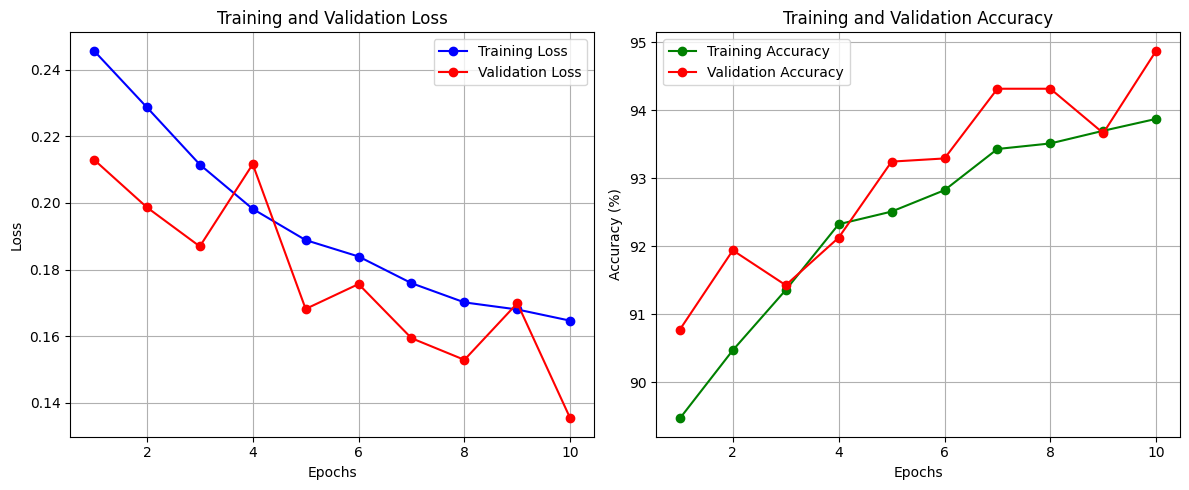

In [114]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# Plotting Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, history['train_loss'], 'bo-', label='Training Loss')
plt.plot(epochs, history['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Training and Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, history['train_accuracy'], 'go-', label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [115]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 34368


In [116]:
def evaluate_model(model, test_loader):
    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    print(f"Test Loss: {test_loss/len(test_loader):.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")

    return all_preds, all_labels

In [117]:
preds, labels = evaluate_model(model, test_loader)

Test Loss: 0.1544
Test Accuracy: 94.20%


In [118]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds, target_names=test_dataset.classes))

              precision    recall  f1-score   support

   broadleaf       0.78      0.64      0.70       358
       grass       0.90      0.89      0.90      1056
        soil       1.00      1.00      1.00       975
     soybean       0.96      0.99      0.97      2213

    accuracy                           0.94      4602
   macro avg       0.91      0.88      0.89      4602
weighted avg       0.94      0.94      0.94      4602



Custom Model 2

In [136]:
class CustomCNN2(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN2, self).__init__()

        self.conv1 = nn.Conv2d(3, 256, 3)
        self.conv2 = nn.Conv2d(256, 128, 3)
        self.conv3 = nn.Conv2d(128, 64, 3)
        self.conv4 = nn.Conv2d(64, 32, 3)
        self.conv5 = nn.Conv2d(32, 8, 3)

        self.pool = nn.MaxPool2d(2, 2)

        # ❗ CORRECT input size
        self.fc1 = nn.Linear(8, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = self.pool(F.relu(self.conv5(x)))

        x = x.view(x.size(0), -1)  # → 8

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

Compiling the model

In [137]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model2 = CustomCNN2(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [138]:
total_params = sum(p.numel() for p in model2.parameters())
print("Total parameters:", total_params)

Total parameters: 414956


In [139]:
history2=train_model(model2, train_loader, val_loader, epochs=15)

Epoch [1/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [2/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [3/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [4/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [5/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [6/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [7/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [8/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [9/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [10/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val Loss: 1.4018
Val Accuracy: 22.45%

Epoch [11/15]
Train Loss: 1.4011
Train Accuracy: 23.08%
Val

In [140]:
history2['train_accuracy'][:-1]

[23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938,
 23.081402119482938]

In [141]:
preds, labels = evaluate_model(model2, test_loader)

Test Loss: 1.4013
Test Accuracy: 22.95%


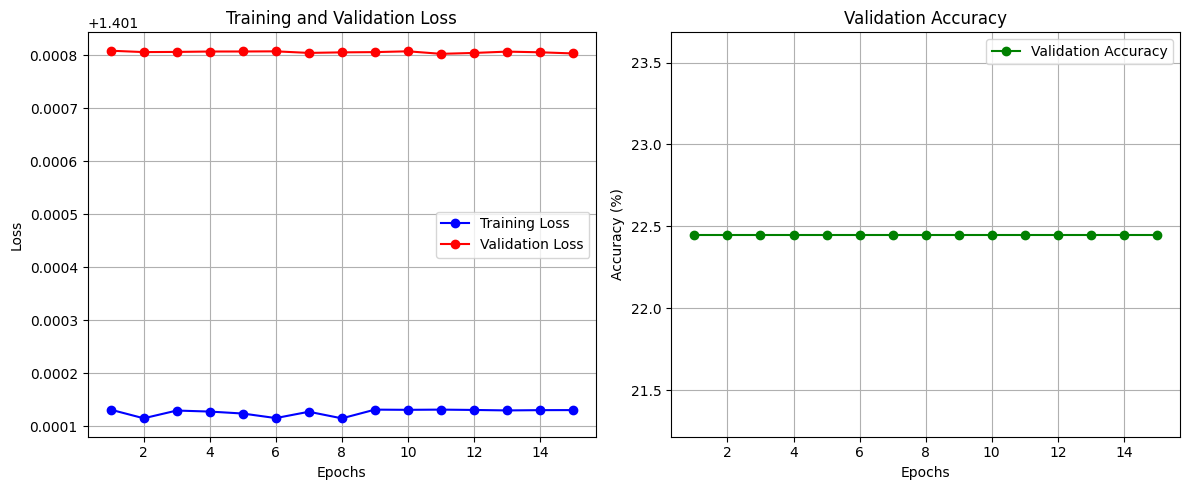

In [142]:
epochs = range(1, len(history2['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# Plotting Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, history2['train_loss'], 'bo-', label='Training Loss')
plt.plot(epochs, history2['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, history2['train_accuracy'], 'ro-', label='Training Accuracy')
plt.plot(epochs, history2['val_accuracy'], 'go-', label='Validation Accuracy')
plt.title('Training Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Custom Model 3

In [171]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN3(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN3, self).__init__()

        # First 4 conv layers (NO pooling)
        self.conv1 = nn.Conv2d(3, 1028, 3)
        self.conv2 = nn.Conv2d(1028, 512, 3)
        self.conv3 = nn.Conv2d(512, 256, 3)
        self.conv4 = nn.Conv2d(256, 128, 3)

        # Last 4 conv layers (WITH pooling)
        self.conv5 = nn.Conv2d(128, 64, 3)
        self.conv6 = nn.Conv2d(64, 32, 3)
        self.conv7 = nn.Conv2d(32, 16, 3)
        self.conv8 = nn.Conv2d(16, 8, 3)

        self.pool = nn.MaxPool2d(2, 2)

        # 🔥 Use adaptive pooling to FORCE (2×2) as paper says
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))

        # Now flatten = 8 × 2 × 2 = 32
        self.fc1 = nn.Linear(32, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        # No pooling
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))

        # With pooling
        x = self.pool(F.relu(self.conv5(x)))
        x = self.pool(F.relu(self.conv6(x)))
        x = self.pool(F.relu(self.conv7(x)))
        x = self.pool(F.relu(self.conv8(x)))

        # 🔥 Force final shape (2×2)
        x = self.adaptive_pool(x)

        x = x.view(x.size(0), -1)  # → 32

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [144]:
# changed batch size to 16
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [172]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model4 = CustomCNN4(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model4.parameters(), lr=0.0001)

In [173]:
total_params = sum(p.numel() for p in model4.parameters())
print("Total parameters:", total_params)

Total parameters: 6368748


In [ ]:
history3=train_model(model4, train_loader, val_loader, epochs=15)

In [ ]:
history3['train_accuracy'][:-1]

In [ ]:
print("hello")

In [ ]:
preds, labels = evaluate_model(model4, test_loader)

In [ ]:
epochs = range(1, len(history3['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# Plotting Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, history3['train_loss'], 'bo-', label='Training Loss')
plt.plot(epochs, history3['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, history3['train_accuracy'], 'ro-', label='Training Accuracy')
plt.plot(epochs, history3['val_accuracy'], 'go-', label='Validation Accuracy')
plt.title('Training Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()